# Import Libraries

In [1]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-03-14 15:34:19.951634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773502460.152616      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773502460.207942      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773502460.693788      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773502460.693841      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773502460.693843      24 computation_placer.cc:177] computation placer alr

# Load Dataset

In [2]:
import os
import pandas as pd

dataset_path = "/kaggle/input/datasets/mdshadmanshakibdip18/capstone/Augmented Dataset"

filepaths = []
labels = []

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_path):

        if img_name.lower().endswith((".png",".jpg",".jpeg")):

            img_path = os.path.join(class_path, img_name)

            filepaths.append(img_path)
            labels.append(class_name)


df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 6120


,filepath,label
0,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
1,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
2,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
3,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
4,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy


# Validation Split
# train (80%)
# test (20%)

In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

train_df.to_csv("/kaggle/working/train_split.csv", index=False)
val_df.to_csv("/kaggle/working/val_split.csv", index=False)
test_df.to_csv("/kaggle/working/test_split.csv", index=False)

print("\nTrain/Val/Test CSVs saved successfully!")

Train size: 4406
Validation size: 490
Test size: 1224

Train class distribution:
label
Diabetic Retinopathy    2479
Healthy                 1927
Name: count, dtype: int64

Validation class distribution:
label
Diabetic Retinopathy    276
Healthy                 214
Name: count, dtype: int64

Test class distribution:
label
Diabetic Retinopathy    689
Healthy                 535
Name: count, dtype: int64

Train/Val/Test CSVs saved successfully!


# DenseNet-121

# Image Data Generators

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

# Data Loaders

In [5]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4406 validated image filenames belonging to 2 classes.
Found 490 validated image filenames belonging to 2 classes.
Found 1224 validated image filenames belonging to 2 classes.


# Load Pretrained DenseNet-121

In [6]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1773502499.446451      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Freeze Base Layers

In [7]:
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Classification Layers

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256,activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(1,activation="sigmoid")(x)

model = Model(inputs=base_model.input,outputs=output)

# Compile Model

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

# Early Stop

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train Model (100 Epoch)

In [11]:
start_train = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop]
)

end_train = time.time()

training_time = end_train - start_train
print("Training Time:",training_time)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1773502518.393474      64 service.cc:152] XLA service 0x78b100003240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773502518.393511      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773502521.794767      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/138 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.6406 - loss: 0.6563    

I0000 00:00:1773502533.537064      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


138/138 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.7724 - loss: 0.4800 - val_accuracy: 0.9408 - val_loss: 0.1933
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 101s 730ms/step - accuracy: 0.9128 - loss: 0.2322 - val_accuracy: 0.9571 - val_loss: 0.1540
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 723ms/step - accuracy: 0.9282 - loss: 0.1888 - val_accuracy: 0.9551 - val_loss: 0.1273
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 742ms/step - accuracy: 0.9366 - loss: 0.1584 - val_accuracy: 0.9510 - val_loss: 0.1210
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 727ms/step - accuracy: 0.9426 - loss: 0.1478 - val_accuracy: 0.9510 - val_loss: 0.1215
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 101s 732ms/step - accuracy: 0.9493 - loss: 0.1354 - val_accuracy: 0.9755 - val_loss: 0.0927
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 741ms/step - accuracy: 0.9517 - loss: 0.1229 - val_accuracy: 0.9714 - val_loss: 0.0930
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 717ms/step - accuracy: 0.9560 - loss: 0

# Predictions

In [12]:
start_inf = time.time()

y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

end_inf = time.time()

inference_time = (end_inf - start_inf)/len(test_generator.filenames)

y_true = test_generator.classes

39/39 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step


# Confusion Matrix

In [13]:
tn,fp,fn,tp = confusion_matrix(y_true,y_pred).ravel()

# Metrics Calculation

In [14]:
accuracy = accuracy_score(y_true,y_pred)

precision = precision_score(y_true,y_pred)

recall = recall_score(y_true,y_pred)

f1 = f1_score(y_true,y_pred)

balanced_acc = balanced_accuracy_score(y_true,y_pred)

specificity = tn/(tn+fp)

fnr = fn/(fn+tp)

fpr = fp/(fp+tn)

auc = roc_auc_score(y_true,y_pred_prob)

# Final Metrics Table

In [15]:
results = pd.DataFrame({

"Metric":[
"Accuracy",
"Precision",
"Recall (Sensitivity)",
"F1 Score",
"Balanced Accuracy",
"Specificity",
"False Negative Rate (FNR)",
"False Positive Rate (FPR)",
"AUC-ROC",
"Training Time",
"Inference Time"
],

"Value":[
accuracy,
precision,
recall,
f1,
balanced_acc,
specificity,
fnr,
fpr,
auc,
training_time,
inference_time
]

})

print(results)

                       Metric        Value
0                    Accuracy     0.987745
1                   Precision     0.974453
2        Recall (Sensitivity)     0.998131
3                    F1 Score     0.986150
4           Balanced Accuracy     0.988906
5                 Specificity     0.979681
6   False Negative Rate (FNR)     0.001869
7   False Positive Rate (FPR)     0.020319
8                     AUC-ROC     0.999609
9               Training Time  7675.622927
10             Inference Time     0.041974


# Confusion Matrix Plot

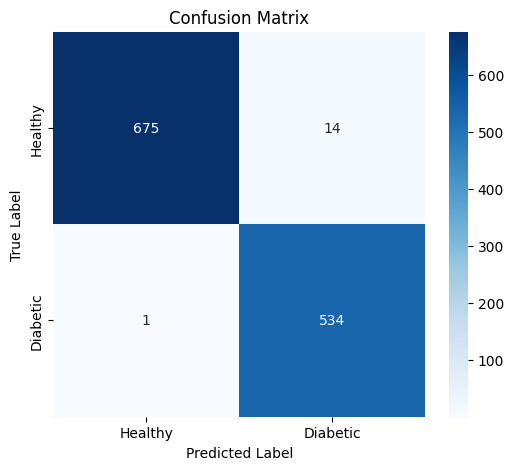

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy","Diabetic"],
    yticklabels=["Healthy","Diabetic"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve Plot

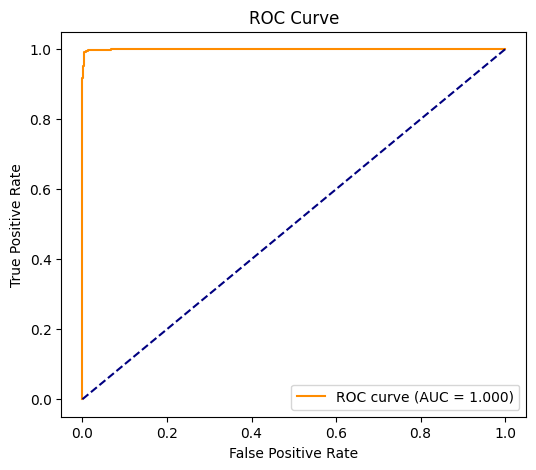

In [17]:
from sklearn.metrics import roc_curve, auc

fpr_curve, tpr_curve, thresholds = roc_curve(y_true, y_pred_prob)

roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(6,5))

plt.plot(fpr_curve, tpr_curve, color="darkorange",
         label="ROC curve (AUC = %0.3f)" % roc_auc)

plt.plot([0,1], [0,1], color="navy", linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

# Short Data Leakage Check

In [18]:
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("Train vs Test duplicates:", len(train_paths & test_paths))
print("Train vs Validation duplicates:", len(train_paths & val_paths))
print("Validation vs Test duplicates:", len(val_paths & test_paths))

Train vs Test duplicates: 0
Train vs Validation duplicates: 0
Validation vs Test duplicates: 0


# Grad-CAM Heatmap

In [19]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        class_idx = tf.argmax(predictions[0])

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [20]:
import matplotlib.pyplot as plt

def show_gradcam(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    plt.figure(figsize=(6,6))

    plt.imshow(superimposed_img.astype("uint8"))

    plt.axis("off")

    plt.title("Grad-CAM Visualization")

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


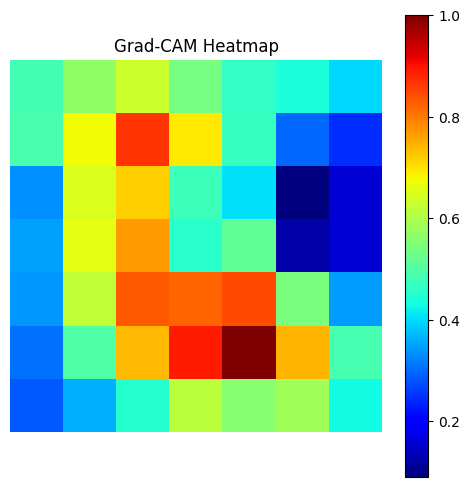

In [21]:
img_path = test_df["filepath"].iloc[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0
last_conv_layer_name = "conv5_block16_concat"

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

# Grad-CAM Visualization

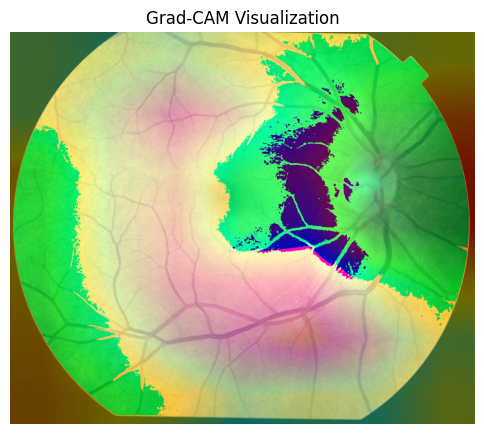

In [22]:
img_path = test_df["filepath"].iloc[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

# DenseNet121 last convolution layer
last_conv_layer_name = "conv5_block16_concat"

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

show_gradcam(img_path, heatmap)